In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks',
    '/home/export/soheuny/SRFinder/soheun/notebooks/draft'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("/home/export/soheuny/SRFinder/soheun")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from typing import Tuple, Any
from constants import FEATURES
from signal_region import compute_sr_stats, get_SR_CR_cut
from events_data import events_from_scdinfo
from dataset import MotherSamples
from training_info import TrainingInfo

SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3
# legend font size
plt.rcParams["legend.fontsize"] = 15

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [6]:
def plot_mean_and_fill_between_std(x, y_list, ax, **kwargs):
    y_mean = np.mean(y_list, axis=0)
    y_std = np.std(y_list, axis=0)
    ax.plot(x, y_mean, **kwargs)
    if "color" in kwargs:
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2, color=kwargs["color"])
    else:
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)
        
def get_events_tst(smeared_hash: str):
    smeared_fvt_tinfo = TrainingInfo.load(smeared_hash)
        
    base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
    base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
    ms_hash = base_fvt_tinfo.ms_hash
    ms_idx = base_fvt_tinfo.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data(loaded_df)
    events_tst = EventsData.from_dataframe(df_tst, features)
    return events_tst


100%|██████████| 50/50 [02:56<00:00,  3.52s/it]


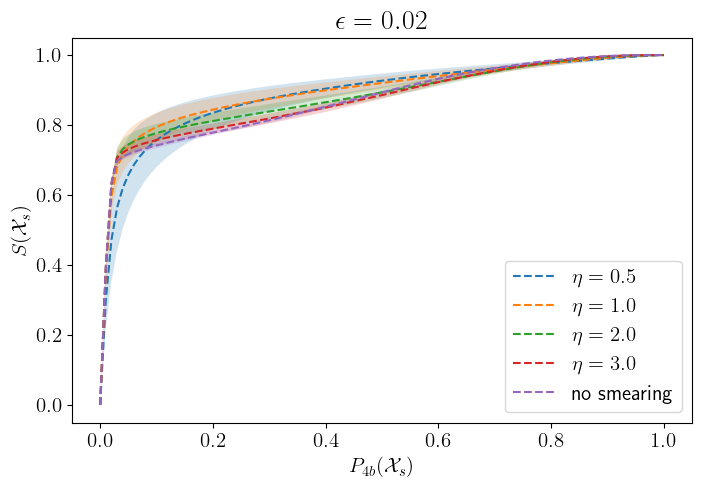

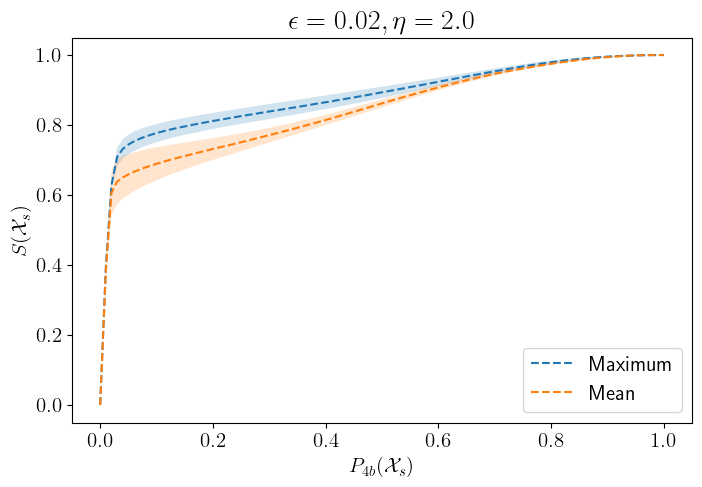

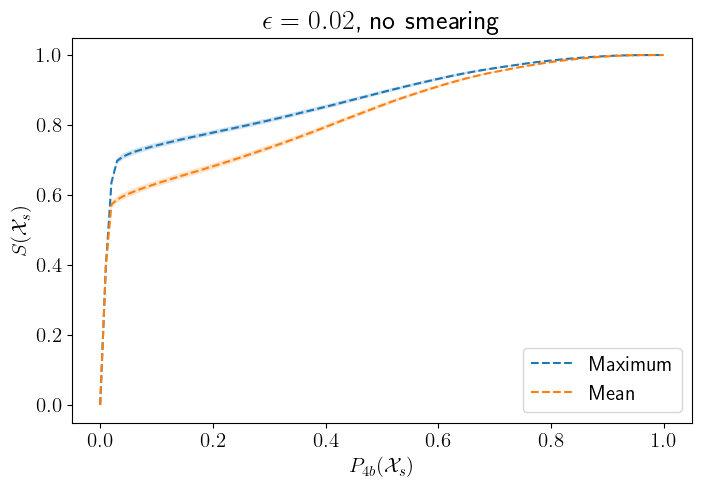

100%|██████████| 50/50 [03:01<00:00,  3.62s/it]


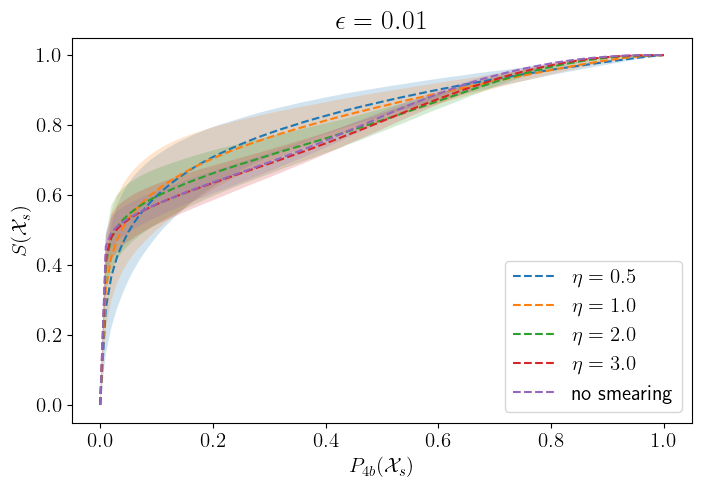

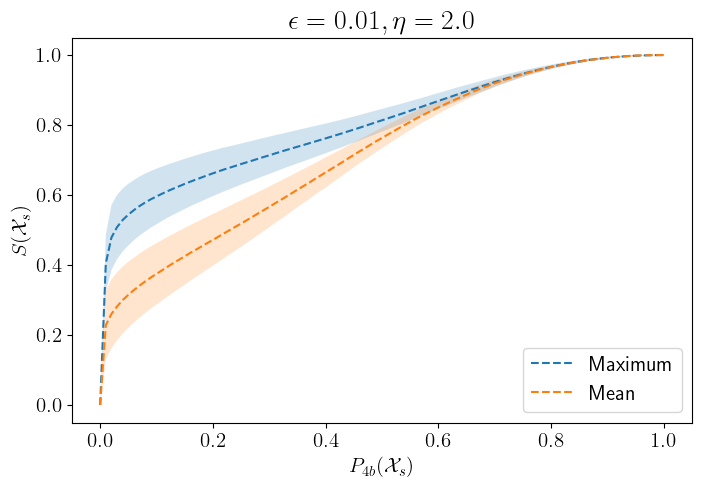

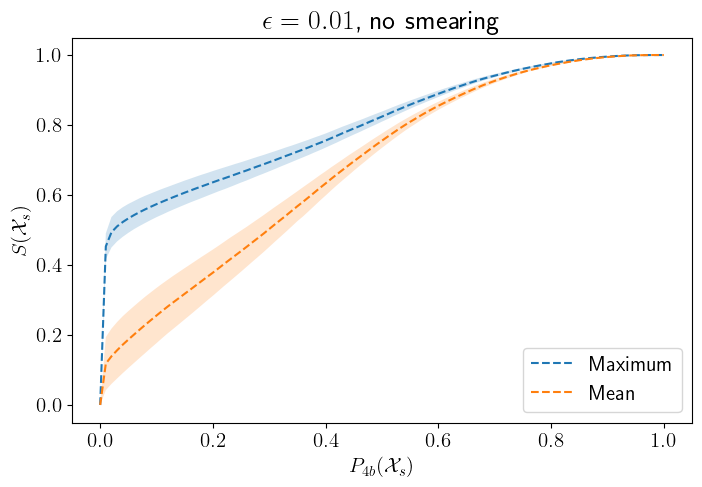

100%|██████████| 50/50 [03:14<00:00,  3.90s/it]


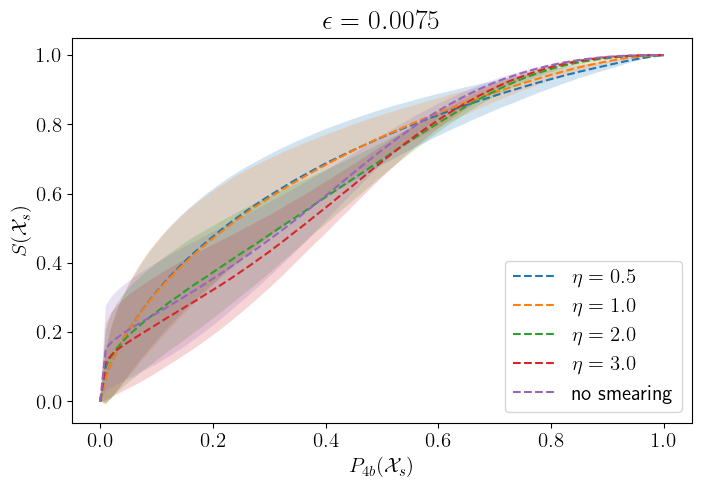

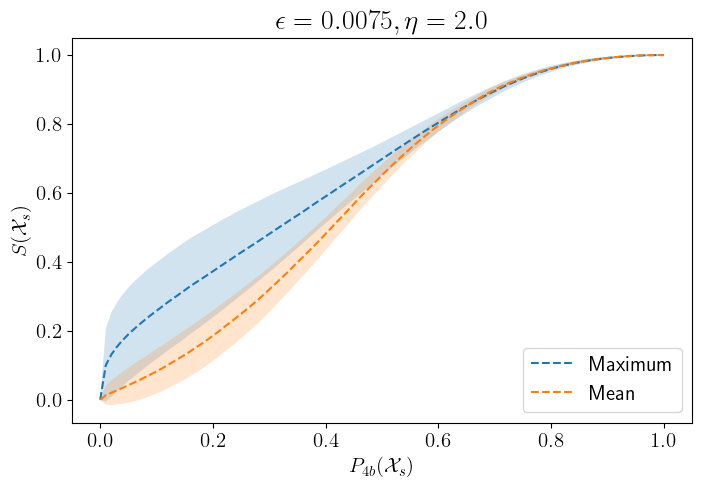

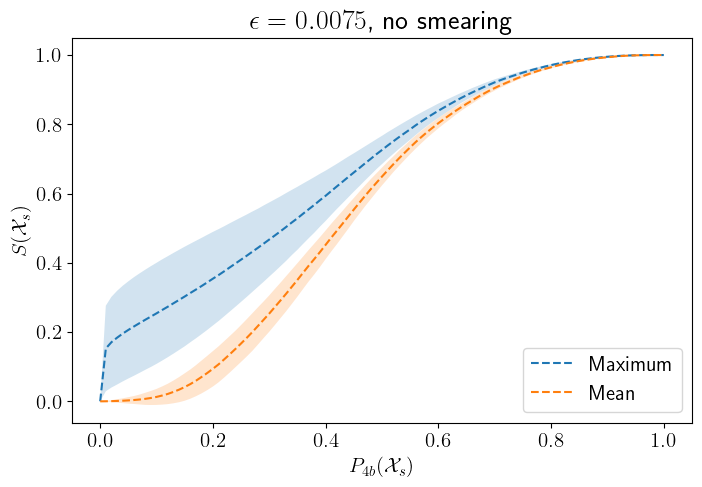

100%|██████████| 50/50 [02:41<00:00,  3.23s/it]


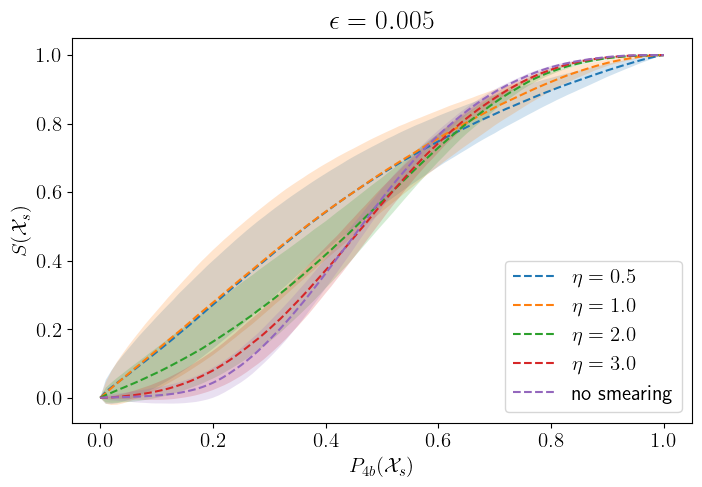

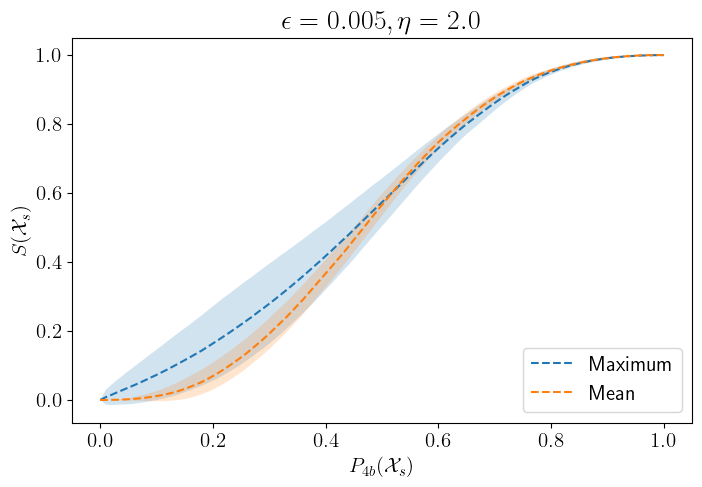

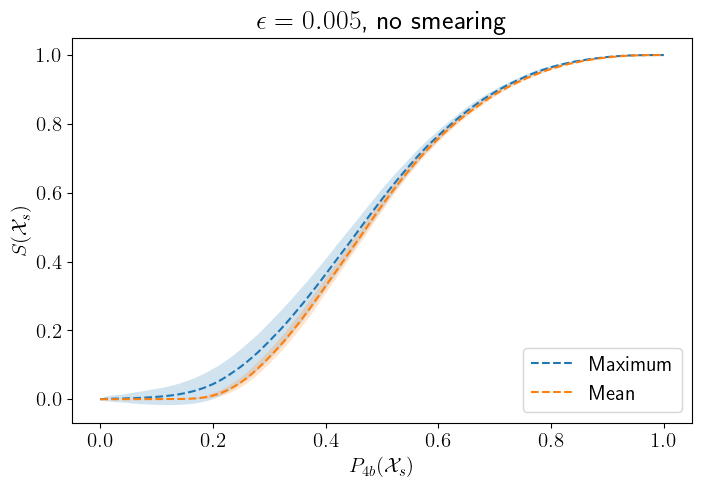

In [ ]:

from plots import get_weights_by_sr_stats
import tqdm

n_3b = 100_0000
seeds = range(50)
signal_ratios = [0.02, 0.01, 0.0075, 0.005]
ensemble_seeds = range(15)
noise_scales = [0.5, 1.0, 2.0, 3.0]

for experiment_name in ["smeared_fvt_training_ensemble"]:
    for signal_ratio in signal_ratios:    
        w_4b_ratio_points = np.arange(0, 1.01, 0.01)
        signal_in_sr_list_dict = {"max_fvt": [], "mean_fvt": []}
        for noise_scale in noise_scales:
            signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"] = []
            signal_in_sr_list_dict[f"mean_sr_stats@{noise_scale}"] = []
        
        for seed in tqdm.tqdm(seeds):
            base_fvt_logit_list = []
            for noise_scale in noise_scales:
                hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                                    "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                        and x["seed"] == seed 
                                                                        and x["n_3b"] == n_3b), 
                                                    "smearing": lambda x: x["noise_scale"] == noise_scale
                                                    }, return_hparams=True, use_cached_metadata=True)
                if len(hashes) != 15:
                    print(f"Expected 15 hashes, got {len(hashes)} for signal_ratio={signal_ratio}, seed={seed}, noise_scale={noise_scale}")
                
                events_tst = get_events_tst(hashes[0])
                SR_stats_list = []
                
                for hash in hashes:
                    smeared_fvt_tinfo = TrainingInfo.load(hash)
                    base_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
                    base_fvt_tinfo = TrainingInfo.load(base_hash)
                    smeared_fvt_logit = smeared_fvt_tinfo.aux_info["smeared_fvt_logit_tst"]
                    base_fvt_logit = base_fvt_tinfo.aux_info["base_fvt_logit_tst"]
                    SR_stats_list.append(base_fvt_logit - smeared_fvt_logit)
                    
                    if noise_scale == 1.0:
                        base_fvt_logit_list.append(base_fvt_logit)
                    
                max_sr_stats = np.max(SR_stats_list, axis=0)
                w_4b_ratio_SR_max, w_signal_ratio_SR_max = get_weights_by_sr_stats(events_tst, max_sr_stats)
                w_signal_ratio_SR_max = np.interp(w_4b_ratio_points, w_4b_ratio_SR_max, w_signal_ratio_SR_max)
                signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"].append(w_signal_ratio_SR_max)
                
                mean_sr_stats = np.mean(SR_stats_list, axis=0)
                w_4b_ratio_SR_mean, w_signal_ratio_SR_mean = get_weights_by_sr_stats(events_tst, mean_sr_stats)
                w_signal_ratio_SR_mean = np.interp(w_4b_ratio_points, w_4b_ratio_SR_mean, w_signal_ratio_SR_mean)
                signal_in_sr_list_dict[f"mean_sr_stats@{noise_scale}"].append(w_signal_ratio_SR_mean)
                
            if len(base_fvt_logit_list) != 15:
                print(f"Expected 15 base_fvt_logit_list, got {len(base_fvt_logit_list)} for signal_ratio={signal_ratio}, seed={seed}")
            base_fvt_logit_max = np.max(base_fvt_logit_list, axis=0)
            w_4b_ratio_base_max, w_signal_ratio_base_max = get_weights_by_sr_stats(events_tst, base_fvt_logit_max)
            w_signal_ratio_base_max = np.interp(w_4b_ratio_points, w_4b_ratio_base_max, w_signal_ratio_base_max)
            signal_in_sr_list_dict["max_fvt"].append(w_signal_ratio_base_max)
            
            base_fvt_logit_mean = np.mean(base_fvt_logit_list, axis=0)
            w_4b_ratio_base_mean, w_signal_ratio_base_mean = get_weights_by_sr_stats(events_tst, base_fvt_logit_mean)
            w_signal_ratio_base_mean = np.interp(w_4b_ratio_points, w_4b_ratio_base_mean, w_signal_ratio_base_mean)
            signal_in_sr_list_dict["mean_fvt"].append(w_signal_ratio_base_mean)
            
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        for noise_scale in noise_scales:
            plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"], 
                                        ax, label=rf"$\eta={noise_scale}$", linestyle="--")
        plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict["max_fvt"], ax, 
                                       label="no smearing", linestyle="--")
        
        ax.set_title(rf"$\epsilon={signal_ratio}$")
        ax.legend(loc="lower right")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        # ax.set_aspect("equal")
        
        plt.savefig(f"./figures/4b_vs_signal_exp={experiment_name}_signal={signal_ratio}_different_noise_scales.pdf", dpi=200)
        plt.show()
        plt.close()
        
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        noise_scale = 2.0
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"], 
                                        ax, label=rf"Maximum", linestyle="--")
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"mean_sr_stats@{noise_scale}"], 
                                        ax, label=rf"Mean", linestyle="--")
        ax.set_title(rf"$\epsilon={signal_ratio}, \eta={noise_scale}$")
        ax.legend(loc="lower right")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        # ax.set_aspect("equal")
        
        plt.savefig(f"./figures/4b_vs_signal_exp={experiment_name}_signal={signal_ratio}_max_vs_mean_sr_stats_eta={noise_scale}.pdf", dpi=200)
        plt.show()
        plt.close()
        
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"max_fvt"], 
                                        ax, label=rf"Maximum", linestyle="--")
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"mean_fvt"], 
                                        ax, label=rf"Mean", linestyle="--")
        ax.set_title(rf"$\epsilon={signal_ratio}$, no smearing")
        ax.legend(loc="lower right")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        # ax.set_aspect("equal")
        
        plt.savefig(f"./figures/4b_vs_signal_exp={experiment_name}_signal={signal_ratio}_max_vs_mean_sr_stats_eta={np.inf}.pdf", dpi=200)
        plt.show()
        plt.close()

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:55<00:00,  1.12s/it]


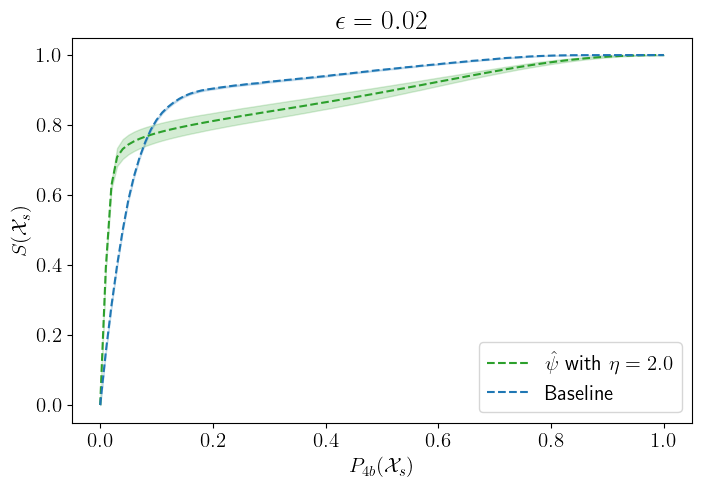

100%|██████████| 50/50 [04:06<00:00,  4.92s/it]


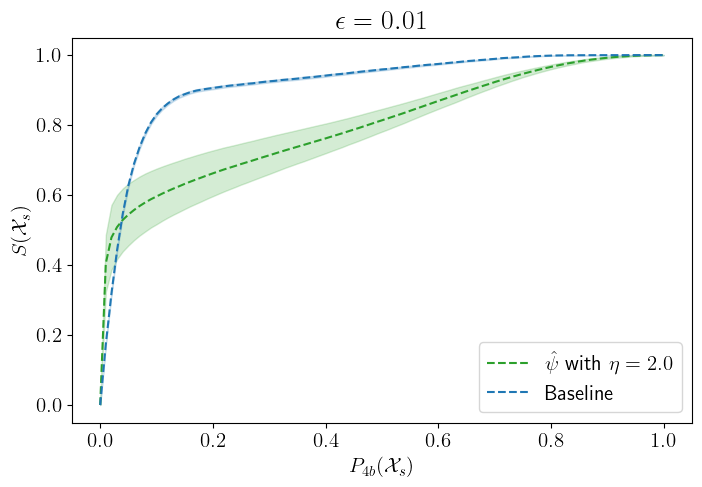

100%|██████████| 50/50 [03:45<00:00,  4.50s/it]


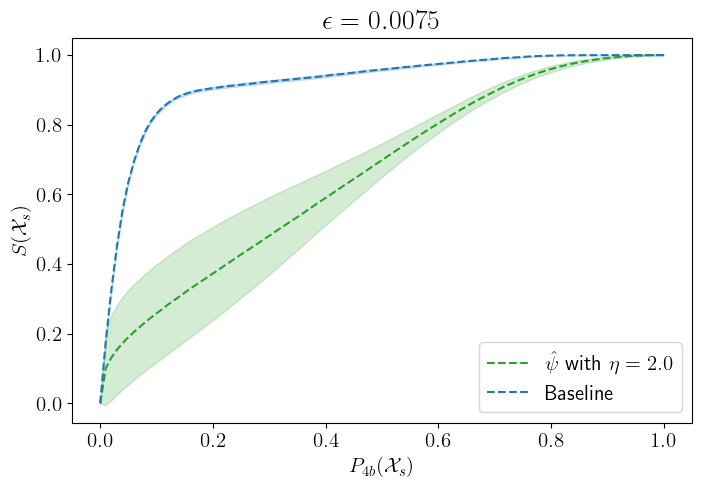

100%|██████████| 50/50 [03:45<00:00,  4.51s/it]


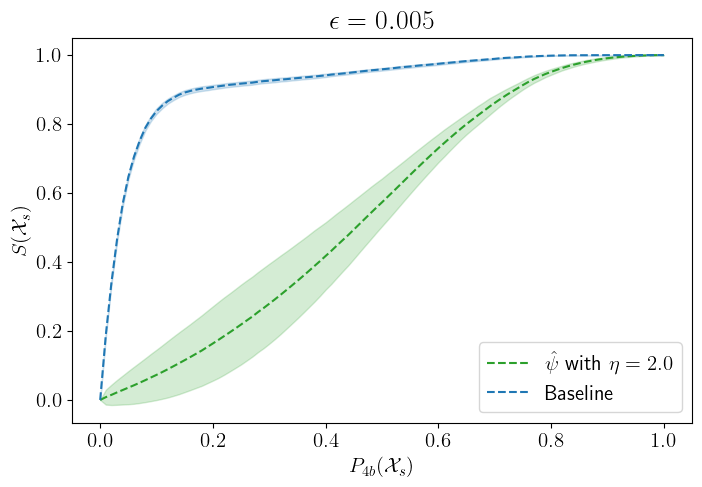

In [16]:
import tqdm

from ancillary_features import get_closest_dijet_masses
from plots import get_weights_by_sr_stats
from training_info import TrainingInfo

import numpy as np
import matplotlib.pyplot as plt

noise_scale = 2.0
signal_ratios = [0.02, 0.01, 0.0075, 0.005]
seeds = range(50)
n_3b = 100_0000

for experiment_name in ["smeared_fvt_training_ensemble"]:
    for signal_ratio in signal_ratios:    
        w_4b_ratio_points = np.arange(0, 1.01, 0.01)
        signal_in_sr_list_dict = {}
        signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"] = []
        signal_in_sr_list_dict["baseline"] = []
        
        for seed in tqdm.tqdm(seeds):
            base_fvt_logit_list = []
            hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                                "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                    and x["seed"] == seed 
                                                                    and x["n_3b"] == n_3b), 
                                                "smearing": lambda x: x["noise_scale"] == noise_scale
                                                }, return_hparams=True, use_cached_metadata=True)
            if len(hashes) != 15:
                print(f"Expected 15 hashes, got {len(hashes)} for signal_ratio={signal_ratio}, seed={seed}, noise_scale={noise_scale}")
            
            events_tst = get_events_tst(hashes[0])
            SR_stats_list = []
            
            for hash in hashes:
                smeared_fvt_tinfo = TrainingInfo.load(hash)
                base_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
                base_fvt_tinfo = TrainingInfo.load(base_hash)
                smeared_fvt_logit = smeared_fvt_tinfo.aux_info["smeared_fvt_logit_tst"]
                base_fvt_logit = base_fvt_tinfo.aux_info["base_fvt_logit_tst"]
                SR_stats_list.append(base_fvt_logit - smeared_fvt_logit)
                
            max_sr_stats = np.max(SR_stats_list, axis=0)
            w_4b_ratio_SR_max, w_signal_ratio_SR_max = get_weights_by_sr_stats(events_tst, max_sr_stats)
            w_signal_ratio_SR_max = np.interp(w_4b_ratio_points, w_4b_ratio_SR_max, w_signal_ratio_SR_max)
            signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"].append(w_signal_ratio_SR_max)
                
            dm_0, dm_1 = get_closest_dijet_masses(events_tst.X_torch)
            dm_0, dm_1 = dm_0.numpy(), dm_1.numpy()
            m_H = 125
            SR_stats_dm = - np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2)    
            w_4b_ratio_baseline, w_signal_ratio_baseline = get_weights_by_sr_stats(events_tst, SR_stats_dm)
            w_signal_ratio_baseline = np.interp(w_4b_ratio_points, w_4b_ratio_baseline, w_signal_ratio_baseline)
            signal_in_sr_list_dict["baseline"].append(w_signal_ratio_baseline)
        
        # Plot the results
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"], 
                                    ax, label=rf"$\hat\psi$ with $\eta={noise_scale}$", linestyle="--", 
                                    color=plt.get_cmap("tab10").colors[2])
        plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict["baseline"], ax, 
                                       label="Baseline", linestyle="--",
                                       color=plt.get_cmap("tab10").colors[0])
        
        ax.set_title(rf"$\epsilon={signal_ratio}$")
        ax.legend(loc="lower right")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        
        plt.savefig(f"./figures/4b_vs_signal_exp={experiment_name}_signal={signal_ratio}_vs_baseline.pdf", dpi=200)
        plt.show()
        plt.close()

# HH4b Resonant 400

100%|██████████| 50/50 [09:19<00:00, 11.19s/it]


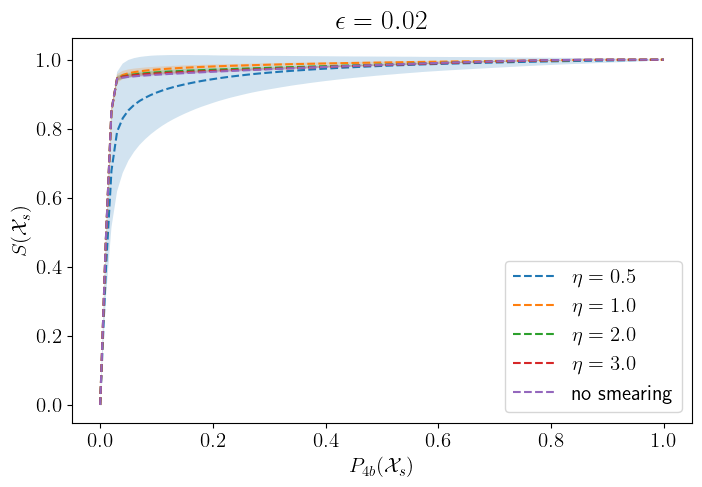

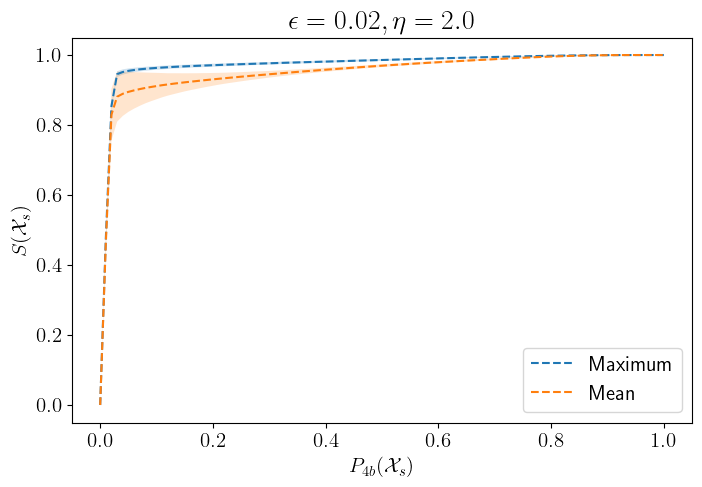

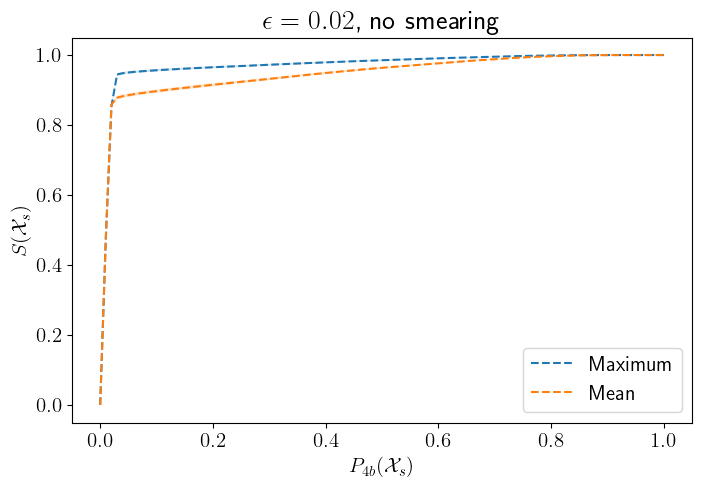

100%|██████████| 50/50 [07:45<00:00,  9.30s/it]


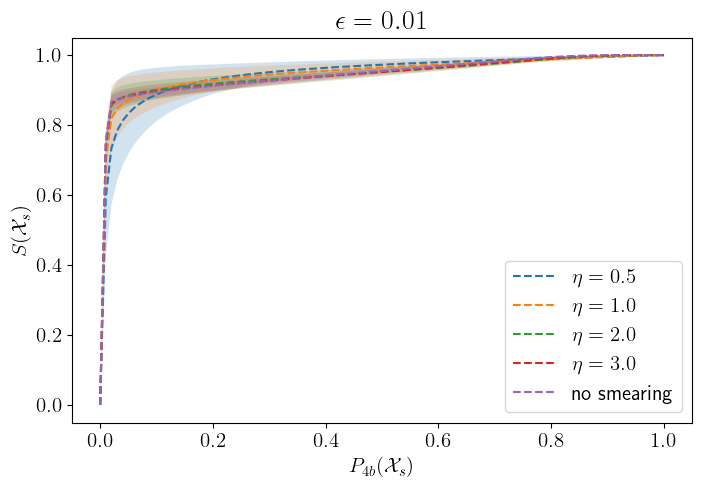

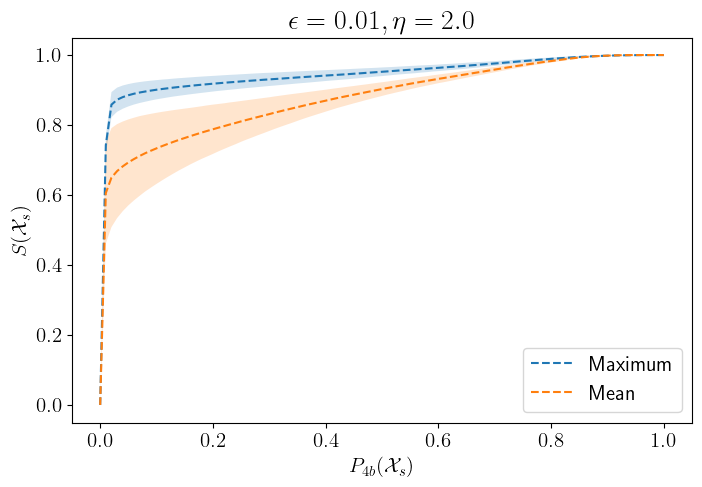

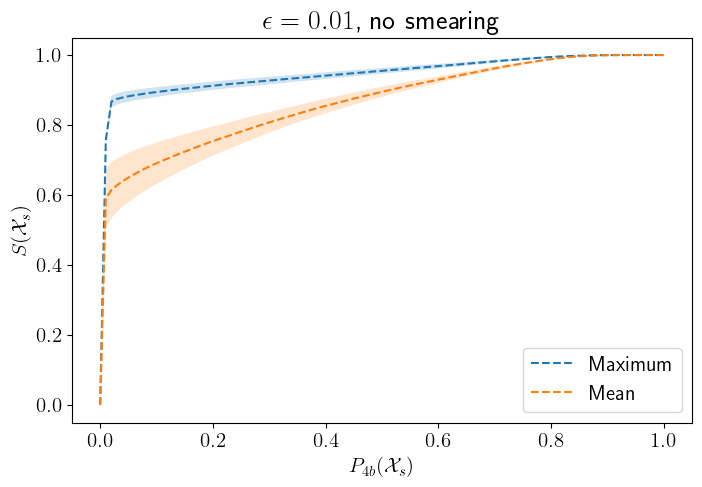

100%|██████████| 50/50 [09:10<00:00, 11.00s/it]


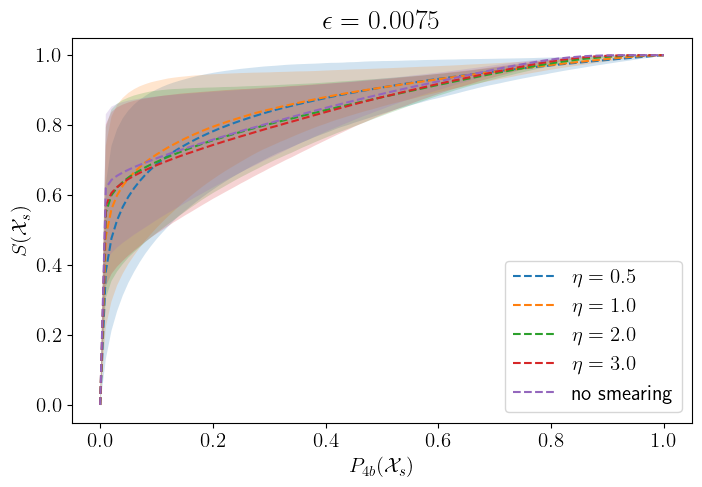

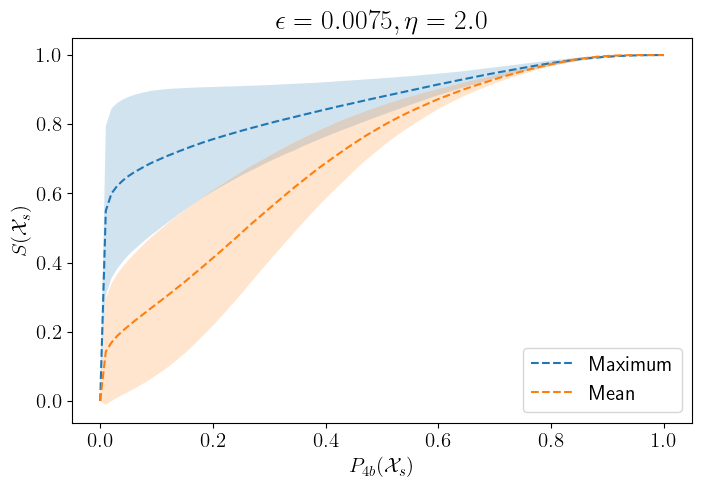

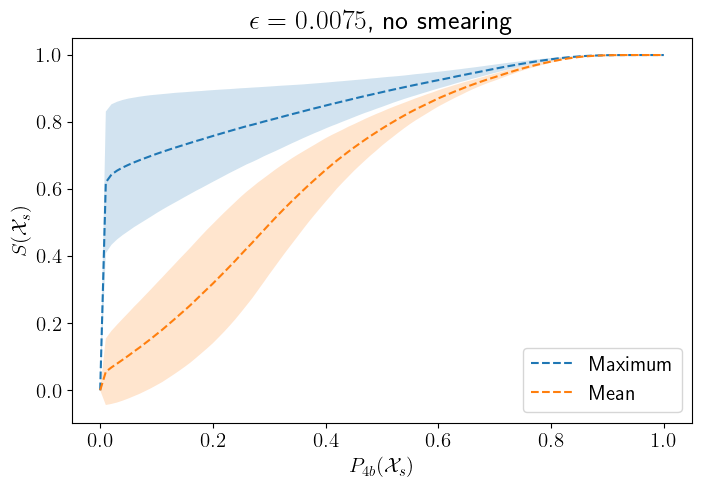

100%|██████████| 50/50 [08:02<00:00,  9.66s/it]


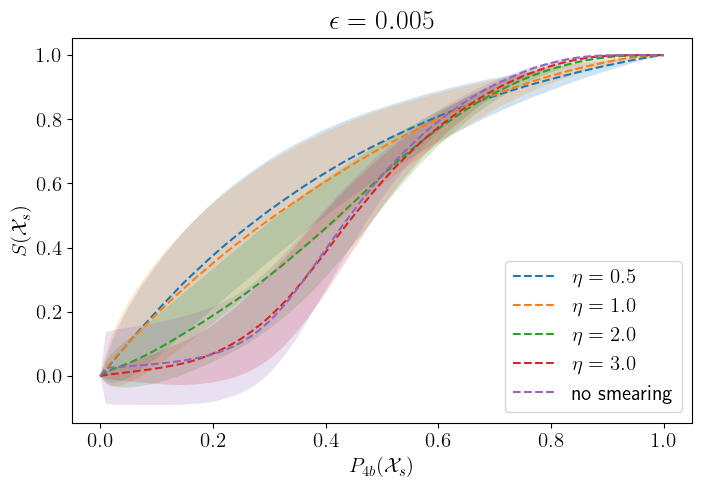

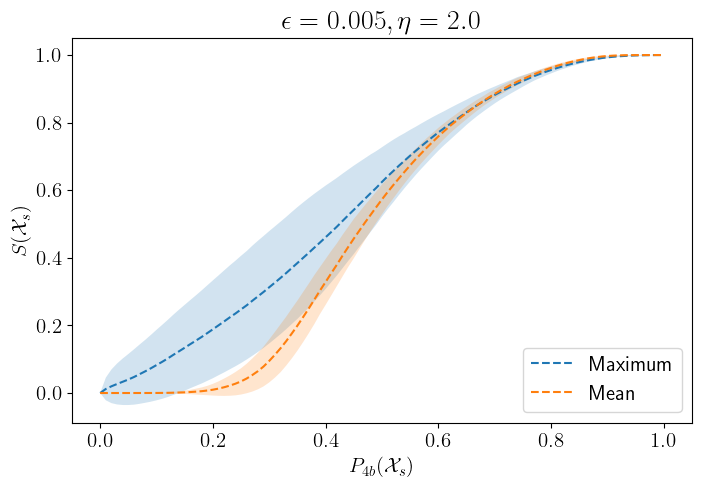

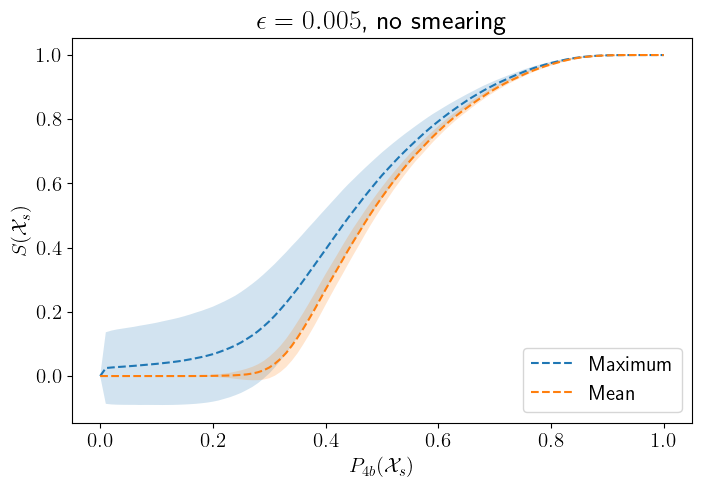

100%|██████████| 50/50 [08:58<00:00, 10.78s/it]


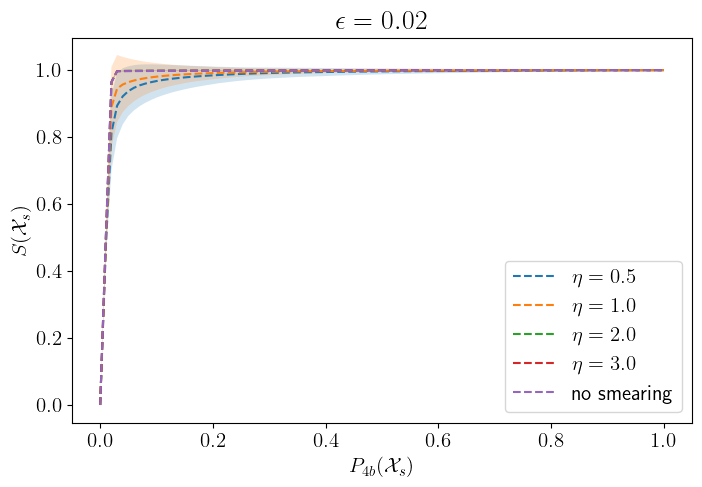

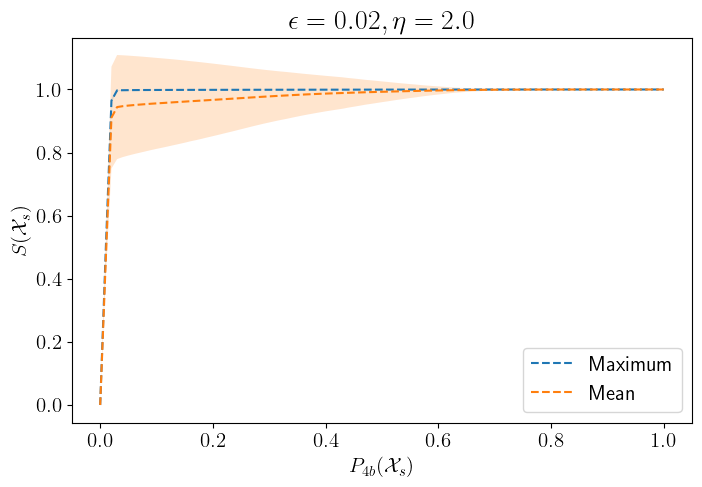

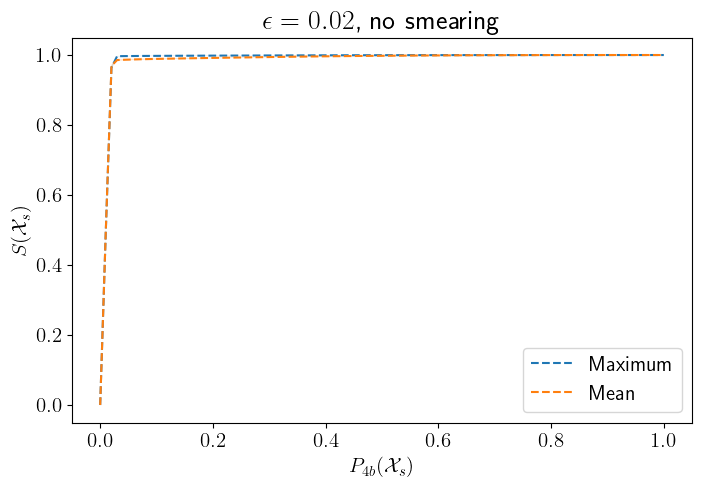

100%|██████████| 50/50 [08:21<00:00, 10.04s/it]


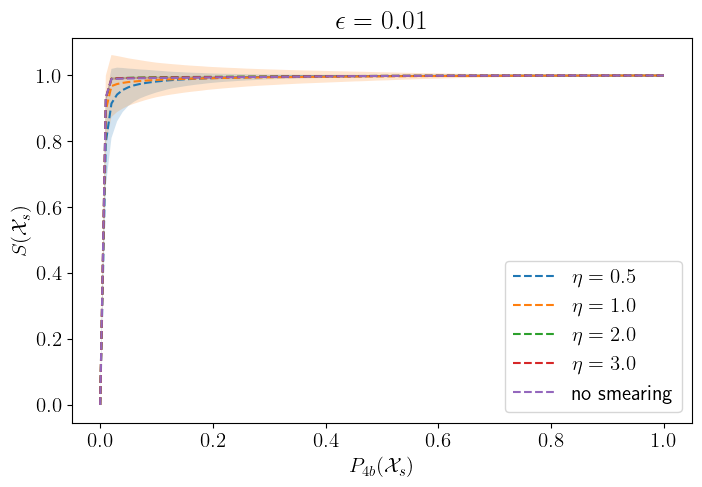

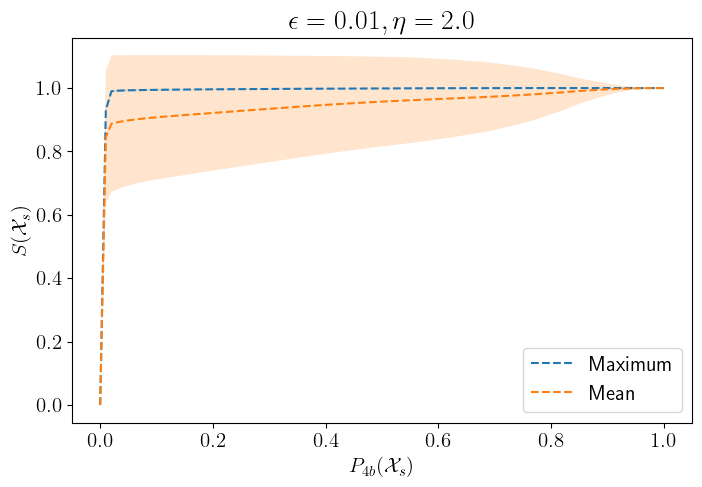

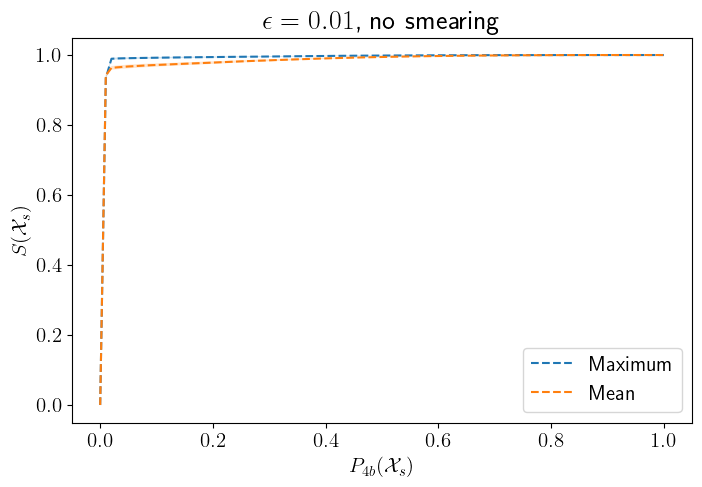

100%|██████████| 50/50 [07:46<00:00,  9.33s/it]


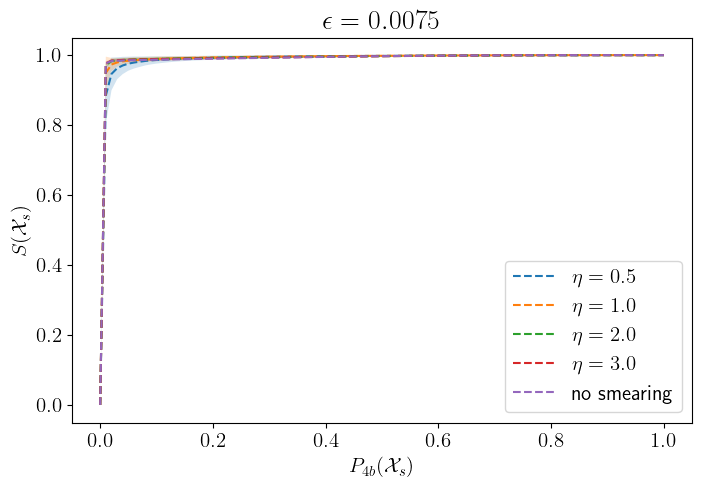

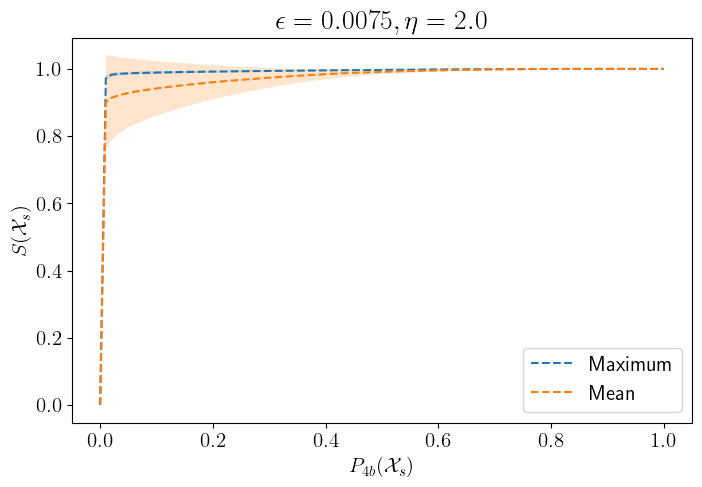

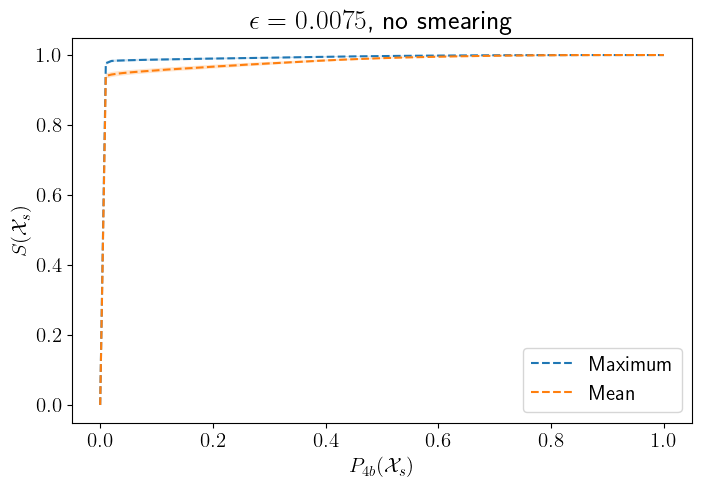

100%|██████████| 50/50 [07:36<00:00,  9.13s/it]


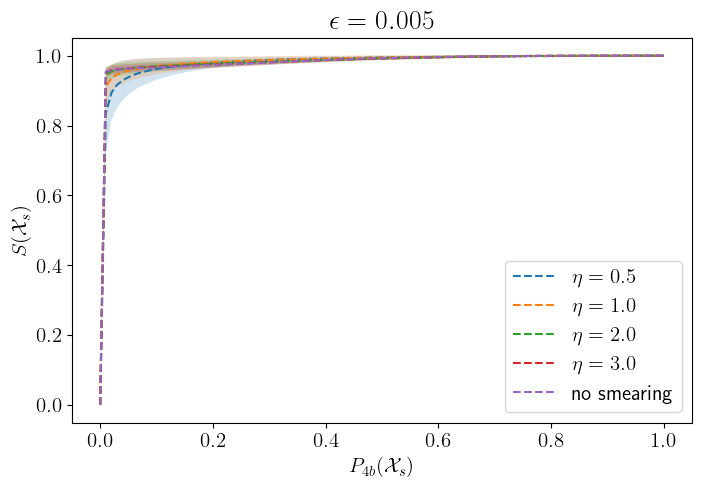

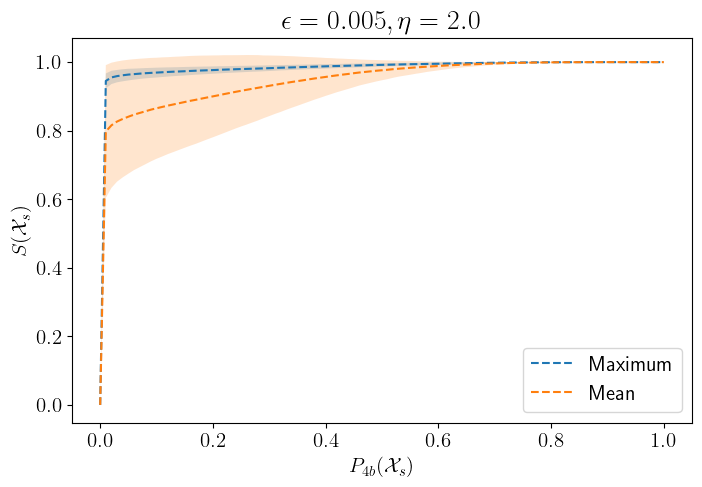

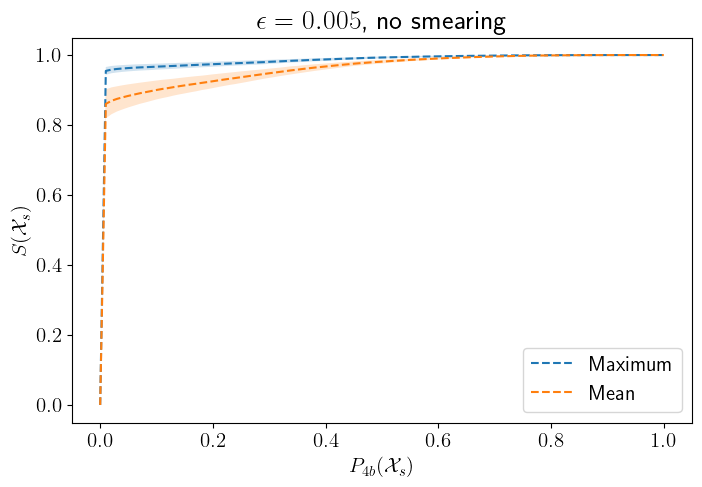

In [7]:

from plots import get_weights_by_sr_stats
import tqdm

n_3b = 100_0000
seeds = range(50)
signal_ratios = [0.02, 0.01, 0.0075, 0.005]
ensemble_seeds = range(15)
noise_scales = [0.5, 1.0, 2.0, 3.0]

for experiment_name in ["smeared_fvt_training_ensemble_HH4b_400",
                        "smeared_fvt_training_ensemble_HH4b_800"]:
    for signal_ratio in signal_ratios:    
        w_4b_ratio_points = np.arange(0, 1.01, 0.01)
        signal_in_sr_list_dict = {"max_fvt": [], "mean_fvt": []}
        for noise_scale in noise_scales:
            signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"] = []
            signal_in_sr_list_dict[f"mean_sr_stats@{noise_scale}"] = []
        
        for seed in tqdm.tqdm(seeds):
            base_fvt_logit_list = []
            for noise_scale in noise_scales:
                hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                                    "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                        and x["seed"] == seed 
                                                                        and x["n_3b"] == n_3b), 
                                                    "smearing": lambda x: x["noise_scale"] == noise_scale
                                                    }, return_hparams=True, use_cached_metadata=True)
                if len(hashes) != 15:
                    print(f"Expected 15 hashes, got {len(hashes)} for signal_ratio={signal_ratio}, seed={seed}, noise_scale={noise_scale}")
                
                events_tst = get_events_tst(hashes[0])
                SR_stats_list = []
                
                for hash in hashes:
                    smeared_fvt_tinfo = TrainingInfo.load(hash)
                    base_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
                    base_fvt_tinfo = TrainingInfo.load(base_hash)
                    smeared_fvt_logit = smeared_fvt_tinfo.aux_info["smeared_fvt_logit_tst"]
                    base_fvt_logit = base_fvt_tinfo.aux_info["base_fvt_logit_tst"]
                    SR_stats_list.append(base_fvt_logit - smeared_fvt_logit)
                    
                    if noise_scale == 1.0:
                        base_fvt_logit_list.append(base_fvt_logit)
                    
                max_sr_stats = np.max(SR_stats_list, axis=0)
                w_4b_ratio_SR_max, w_signal_ratio_SR_max = get_weights_by_sr_stats(events_tst, max_sr_stats)
                w_signal_ratio_SR_max = np.interp(w_4b_ratio_points, w_4b_ratio_SR_max, w_signal_ratio_SR_max)
                signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"].append(w_signal_ratio_SR_max)
                
                mean_sr_stats = np.mean(SR_stats_list, axis=0)
                w_4b_ratio_SR_mean, w_signal_ratio_SR_mean = get_weights_by_sr_stats(events_tst, mean_sr_stats)
                w_signal_ratio_SR_mean = np.interp(w_4b_ratio_points, w_4b_ratio_SR_mean, w_signal_ratio_SR_mean)
                signal_in_sr_list_dict[f"mean_sr_stats@{noise_scale}"].append(w_signal_ratio_SR_mean)
                
            if len(base_fvt_logit_list) != 15:
                print(f"Expected 15 base_fvt_logit_list, got {len(base_fvt_logit_list)} for signal_ratio={signal_ratio}, seed={seed}")
            base_fvt_logit_max = np.max(base_fvt_logit_list, axis=0)
            w_4b_ratio_base_max, w_signal_ratio_base_max = get_weights_by_sr_stats(events_tst, base_fvt_logit_max)
            w_signal_ratio_base_max = np.interp(w_4b_ratio_points, w_4b_ratio_base_max, w_signal_ratio_base_max)
            signal_in_sr_list_dict["max_fvt"].append(w_signal_ratio_base_max)
            
            base_fvt_logit_mean = np.mean(base_fvt_logit_list, axis=0)
            w_4b_ratio_base_mean, w_signal_ratio_base_mean = get_weights_by_sr_stats(events_tst, base_fvt_logit_mean)
            w_signal_ratio_base_mean = np.interp(w_4b_ratio_points, w_4b_ratio_base_mean, w_signal_ratio_base_mean)
            signal_in_sr_list_dict["mean_fvt"].append(w_signal_ratio_base_mean)
            
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        for noise_scale in noise_scales:
            plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"], 
                                        ax, label=rf"$\eta={noise_scale}$", linestyle="--")
        plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict["max_fvt"], ax, 
                                       label="no smearing", linestyle="--")
        
        ax.set_title(rf"$\epsilon={signal_ratio}$")
        ax.legend(loc="lower right")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        # ax.set_aspect("equal")
        
        plt.savefig(f"./figures/4b_vs_signal_exp={experiment_name}_signal={signal_ratio}_different_noise_scales.pdf", dpi=200)
        plt.show()
        plt.close()
        
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        noise_scale = 2.0
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"], 
                                        ax, label=rf"Maximum", linestyle="--")
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"mean_sr_stats@{noise_scale}"], 
                                        ax, label=rf"Mean", linestyle="--")
        ax.set_title(rf"$\epsilon={signal_ratio}, \eta={noise_scale}$")
        ax.legend(loc="lower right")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        # ax.set_aspect("equal")
        
        plt.savefig(f"./figures/4b_vs_signal_exp={experiment_name}_signal={signal_ratio}_max_vs_mean_sr_stats_eta={noise_scale}.pdf", dpi=200)
        plt.show()
        plt.close()
        
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"max_fvt"], 
                                        ax, label=rf"Maximum", linestyle="--")
        plot_mean_and_fill_between_std(w_4b_ratio_points, 
                                       signal_in_sr_list_dict[f"mean_fvt"], 
                                        ax, label=rf"Mean", linestyle="--")
        ax.set_title(rf"$\epsilon={signal_ratio}$, no smearing")
        ax.legend(loc="lower right")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        # ax.set_aspect("equal")
        
        plt.savefig(f"./figures/4b_vs_signal_exp={experiment_name}_signal={signal_ratio}_max_vs_mean_sr_stats_eta={np.inf}.pdf", dpi=200)
        plt.show()
        plt.close()